In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        5 non-null      int64
 1   Study_Hours       5 non-null      int64
 2   Attendance        5 non-null      int64
 3   Previous_Marks    5 non-null      int64
 4   Assignment_Score  5 non-null      int64
 5   Final_Marks       5 non-null      int64
dtypes: int64(6)
memory usage: 372.0 bytes


In [2]:
df.isnull().sum()

Student_ID          0
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Final_Marks         0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.describe()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,4.800000,83.000000,71.600000,76.800000,74.600000
std,1.581139,2.387467,10.368221,13.794927,13.663821,14.064139
min,1.000000,2.000000,70.000000,55.000000,60.000000,58.000000
25%,2.000000,3.000000,75.000000,60.000000,65.000000,62.000000
50%,3.000000,5.000000,85.000000,75.000000,82.000000,78.000000
75%,4.000000,6.000000,90.000000,80.000000,85.000000,85.000000
max,5.000000,8.000000,95.000000,88.000000,92.000000,90.000000


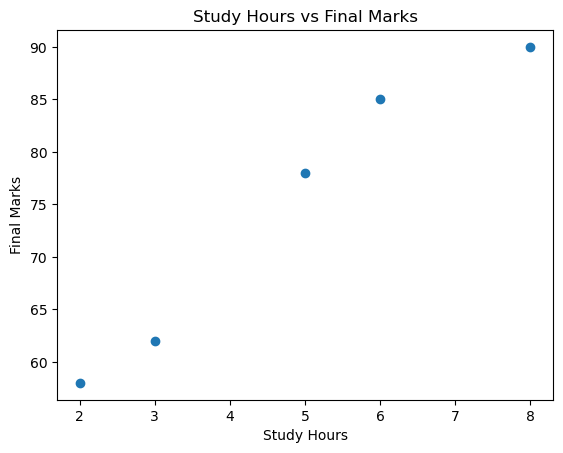

In [6]:
import matplotlib.pyplot as plt

plt.scatter(df["Study_Hours"], df["Final_Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.title("Study Hours vs Final Marks")

plt.show()

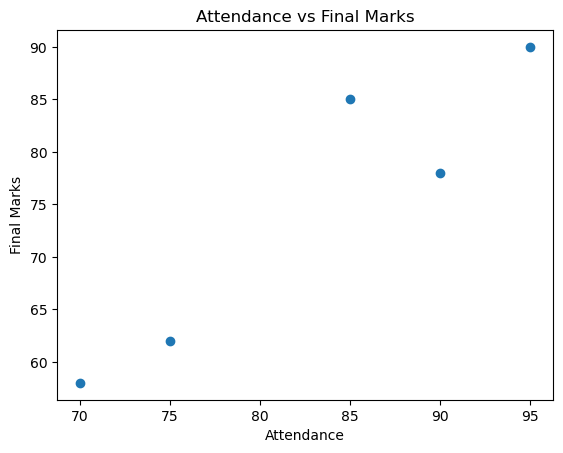

In [7]:
plt.scatter(df["Attendance"], df["Final_Marks"])

plt.xlabel("Attendance")
plt.ylabel("Final Marks")
plt.title("Attendance vs Final Marks")

plt.show()

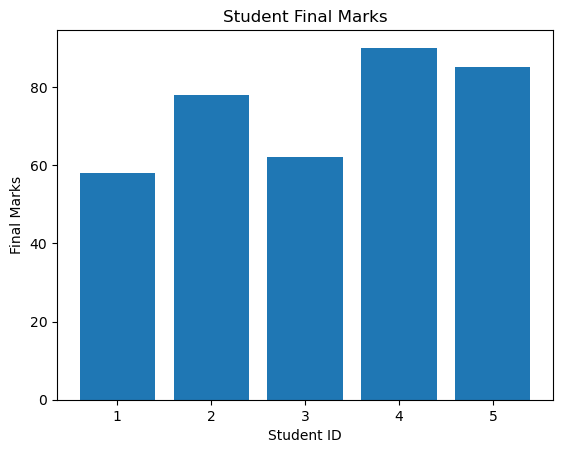

In [8]:
plt.bar(df["Student_ID"], df["Final_Marks"])

plt.xlabel("Student ID")
plt.ylabel("Final Marks")
plt.title("Student Final Marks")

plt.show()

In [10]:
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]
y = df["Final_Marks"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred = model.predict(X_test)

print(y_pred)

[74.06698565]


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 15.468601909296934
R2 Score: nan


C:\Users\Siddhi Jaid\anaconda3\anaconda.siddhi\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

data = {
    "Student_ID": range(1, n + 1),
    "Study_Hours": np.random.randint(1, 11, n),
    "Attendance": np.random.randint(50, 101, n),
    "Previous_Marks": np.random.randint(35, 96, n),
    "Assignment_Score": np.random.randint(40, 101, n)
}

df = pd.DataFrame(data)

df["Final_Marks"] = (
    0.25 * df["Study_Hours"] * 5 +
    0.25 * df["Attendance"] +
    0.30 * df["Previous_Marks"] +
    0.20 * df["Assignment_Score"] +
    np.random.normal(0, 5, n)
)

df["Final_Marks"] = df["Final_Marks"].clip(0, 100).round(2)

df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Final_Marks
0,1,7,90,83,56,69.88
1,2,4,79,39,98,55.91
2,3,8,66,94,84,72.85
3,4,5,98,78,82,69.40
4,5,7,69,84,73,69.34


In [16]:
df.shape

(500, 6)

In [18]:
X = df[["Study_Hours", "Attendance",
        "Previous_Marks", "Assignment_Score"]]

y = df["Final_Marks"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 4)
Testing data: (100, 4)


In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 3.931264525142518
MSE: 22.258047555870995
R2 Score: 0.7318950224318245


In [23]:
new_student = [[6, 85, 75, 80]]

prediction = model.predict(new_student)

print("Predicted Final Marks:", round(prediction[0], 2))

Predicted Final Marks: 67.49


C:\Users\Siddhi Jaid\anaconda3\anaconda.siddhi\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [24]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Marks": [75],
    "Assignment_Score": [80]
})

prediction = model.predict(new_student)

print("Student Performance Prediction")
print("------------------------------")
print("Study Hours:", 6)
print("Attendance:", "85%")
print("Previous Marks:", 75)
print("Assignment Score:", 80)
print("Predicted Final Marks:", round(prediction[0], 2))

Student Performance Prediction
------------------------------
Study Hours: 6
Attendance: 85%
Previous Marks: 75
Assignment Score: 80
Predicted Final Marks: 67.49
